[INFO] Descargando catalogo desde AstroDataLab sin token...
[INFO] Catalogo guardado en: pspl_trilegal_blending_output/simdr2_cache_ra267.925_dec-29.152_hs0.100_lim300000.csv
[INFO] Catalogo cargado con 300000 estrellas.
[INFO] Columnas disponibles:
['ra', 'dec', 'gall', 'galb', 'elon', 'elat', 'm_ini', 'logage', 'm_h', 'mu0', 'av', 'mratio', 'mass', 'logl', 'logte', 'logg', 'mcoretp', 'c_o', 'period0', 'period1', 'period2', 'period3', 'period4', 'mloss', 'tau1m', 'x', 'y', 'xc', 'xn', 'xo', 'cexcess', 'z', 'mbolmag', 'umag', 'gmag', 'rmag', 'imag', 'zmag', 'ymag', 'gaia_gmag', 'g_bpmag', 'g_rpmag', 'velu', 'velv', 'velw', 'vrad', 'pmracosd', 'pmdec', 'random_id', 'htm9', 'ring256', 'nest4096', 'gc', 'label', 'pmode']
[INFO] Fuente elegida: source_index = 4714
[INFO] Figura guardada en: pspl_trilegal_blending_output/pspl_blended_lightcurve.png


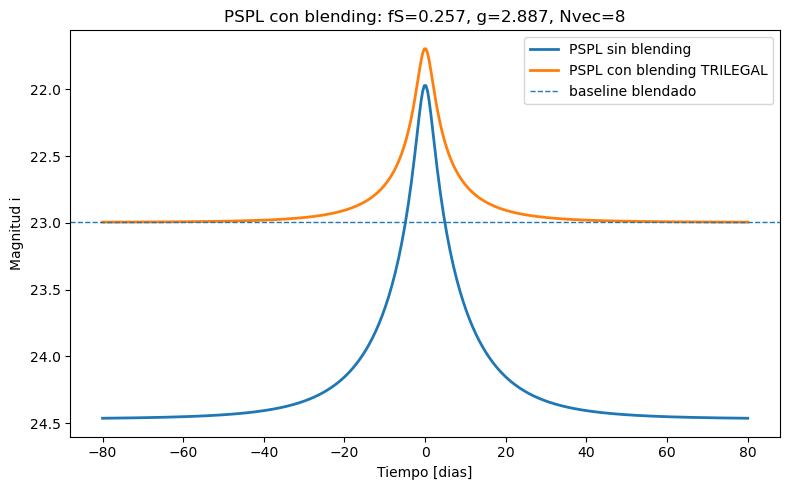


========== RESUMEN ==========
RA fuente              = 267.8361126460963
Dec fuente             = -29.24695507999849
Banda                  = i
mag fuente             = 24.4700
mag baseline blendado  = 22.9959
F_source               = 1.629296e+01
F_blend                = 4.703876e+01
F_base                 = 6.333172e+01
f_source               = 0.2573
g_blend = F_blend/FS   = 2.8871
N vecinas usadas       = 8
Radio blending         = 0.8 arcsec
FWHM PSF               = 0.8 arcsec
CSV guardado en        = pspl_trilegal_blending_output/pspl_blended_lightcurve.csv
True/blending guardado = pspl_trilegal_blending_output/true_parameters_and_blending.json


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from io import StringIO
from scipy.spatial import cKDTree

from dl import queryClient as qc
from dl.helpers.utils import convert


# ============================================================
# CONFIGURACION
# ============================================================

path_to_save_model = "./pspl_trilegal_blending_output"
outdir = Path(path_to_save_model)
outdir.mkdir(parents=True, exist_ok=True)

# Region local del cielo.
# Usar una region local es importante para que las vecinas sean fisicas.
ra_center = 267.925
dec_center = -29.152
half_size_deg = 0.10

galb_max = 3.0
limit = 300000
timeout = 1200

# Banda LSST para la curva de luz
band = "i"

# Parametros PSPL
t0 = 0.0
u0 = 0.1
tE = 20.0

t_min = -80.0
t_max = 80.0
n_points = 400

# Blending / PSF
radius_arcsec = 0.8
fwhm_arcsec = 0.8
psf_weighted = True

# Seleccion de fuente
source_index = None       # Si es None, elige una fuente aleatoria
max_source_mag = 24.5
random_state = 123

# Ruido opcional en magnitud.
# Usar None para curva sin ruido.
mag_err = None
# mag_err = 0.02


# ============================================================
# CONSTANTES Y UTILIDADES
# ============================================================

ARCSEC_PER_RAD = 206264.80624709636


def mag_to_flux(mag, zp=27.5):
    """
    Convierte magnitud AB a flujo relativo.
    El zero point es arbitrario si se usa consistentemente.
    """
    return 10.0 ** (-0.4 * (np.asarray(mag) - zp))


def flux_to_mag(flux, zp=27.5):
    """
    Convierte flujo relativo a magnitud AB.
    """
    flux = np.asarray(flux)
    flux = np.maximum(flux, 1e-300)
    return zp - 2.5 * np.log10(flux)


def pspl_magnification(t, t0, u0, tE):
    """
    Magnificacion PSPL.
    """
    tau = (t - t0) / tE
    u = np.sqrt(u0**2 + tau**2)

    A = (u**2 + 2.0) / (u * np.sqrt(u**2 + 4.0))

    return A


def radec_to_unit_vector(ra_deg, dec_deg):
    """
    Convierte RA, Dec en grados a vectores unitarios 3D.
    Sirve para buscar vecinas angularmente con KDTree.
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)

    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    return np.vstack([x, y, z]).T


def angular_radius_to_chord(radius_arcsec):
    """
    Convierte radio angular en arcsec a radio de cuerda
    sobre la esfera unitaria.
    """
    theta = radius_arcsec / ARCSEC_PER_RAD
    return 2.0 * np.sin(theta / 2.0)


def angular_separation_arcsec(v0, vj):
    """
    Separacion angular entre un vector unitario v0 y varios vectores vj.
    """
    chord = np.linalg.norm(vj - v0, axis=1)
    theta = 2.0 * np.arcsin(np.clip(chord / 2.0, 0.0, 1.0))
    return theta * ARCSEC_PER_RAD


# ============================================================
# QUERY Y CACHE SIN TOKEN
# ============================================================

def build_local_simdr2_query(
    ra_center,
    dec_center,
    half_size_deg,
    galb_max=3.0,
    limit=300000,
):
    """
    Query local a lsst_sim.simdr2.

    Para blending conviene usar una region local en RA, Dec.
    Si se usa solo abs(galb) <= 3 con LIMIT, el catalogo puede quedar
    submuestreado espacialmente y el blending sale artificialmente bajo.
    """
    ra_min = ra_center - half_size_deg
    ra_max = ra_center + half_size_deg
    dec_min = dec_center - half_size_deg
    dec_max = dec_center + half_size_deg

    query = f"""
SELECT *
FROM lsst_sim.simdr2
WHERE abs(galb) <= {galb_max}
AND ra BETWEEN {ra_min} AND {ra_max}
AND dec BETWEEN {dec_min} AND {dec_max}
LIMIT {limit}
"""
    return query


def run_public_datalab_query(query, timeout=1200):
    """
    Ejecuta una query publica en AstroDataLab sin authClient y sin token.

    Dependiendo de la version instalada de dl, qc.query puede devolver
    directamente un string CSV o un objeto convertible con convert(..., "pandas").
    """
    result = qc.query(
        sql=query,
        fmt="csv",
        timeout=timeout,
    )

    try:
        df = convert(result, "pandas")
    except Exception:
        df = pd.read_csv(StringIO(result))

    return df


def load_or_download_catalog_no_token(query, cache_file, timeout=1200):
    """
    Carga el catalogo desde cache si existe.
    Si no existe, descarga desde AstroDataLab sin token y guarda CSV.
    """
    cache_file = Path(cache_file)
    cache_file.parent.mkdir(parents=True, exist_ok=True)

    if cache_file.exists():
        print(f"[INFO] Cargando catalogo desde cache: {cache_file}")
        df = pd.read_csv(cache_file)
    else:
        print("[INFO] Descargando catalogo desde AstroDataLab sin token...")
        df = run_public_datalab_query(query, timeout=timeout)
        df.to_csv(cache_file, index=False)
        print(f"[INFO] Catalogo guardado en: {cache_file}")

    return df


# ============================================================
# CLASE PARA BLENDING CON VECINAS DE TRILEGAL
# ============================================================

class TrilegalNeighborBlender:
    """
    Calcula blending usando estrellas vecinas del catalogo TRILEGAL/simdr2.

    El catalogo debe tener columnas:
    ra, dec, umag, gmag, rmag, imag, zmag, ymag
    """

    def __init__(
        self,
        catalog,
        bands=("u", "g", "r", "i", "z", "y"),
        ra_col="ra",
        dec_col="dec",
        mag_suffix="mag",
        zp=27.5,
    ):
        self.bands = tuple(bands)
        self.ra_col = ra_col
        self.dec_col = dec_col
        self.mag_suffix = mag_suffix
        self.zp = zp

        needed_cols = [ra_col, dec_col] + [self.mag_col(b) for b in self.bands]
        missing = [c for c in needed_cols if c not in catalog.columns]

        if len(missing) > 0:
            raise ValueError(f"Faltan columnas en el catalogo: {missing}")

        df = catalog.copy().reset_index(drop=True)

        good_pos = (
            np.isfinite(df[ra_col].values)
            & np.isfinite(df[dec_col].values)
        )

        df = df.loc[good_pos].reset_index(drop=True)

        self.df = df

        self.unit_vectors = radec_to_unit_vector(
            self.df[ra_col].values,
            self.df[dec_col].values,
        )

        self.tree = cKDTree(self.unit_vectors)

    def mag_col(self, band):
        return f"{band}{self.mag_suffix}"

    def choose_random_source(self, band="i", max_mag=None, random_state=None):
        """
        Elige una fuente aleatoria con magnitud finita en la banda dada.
        Opcionalmente exige mag < max_mag.
        """
        rng = np.random.default_rng(random_state)

        mag = self.df[self.mag_col(band)].values

        good = np.isfinite(mag)

        if max_mag is not None:
            good &= mag < max_mag

        indices = np.where(good)[0]

        if len(indices) == 0:
            raise RuntimeError("No hay fuentes validas para elegir.")

        return int(rng.choice(indices))

    def get_neighbors(self, source_index, radius_arcsec):
        """
        Devuelve indices de estrellas vecinas dentro de radius_arcsec.
        Excluye la fuente.
        """
        chord_radius = angular_radius_to_chord(radius_arcsec)

        v0 = self.unit_vectors[source_index]

        idx = self.tree.query_ball_point(v0, r=chord_radius)
        idx = np.array(idx, dtype=int)

        idx = idx[idx != source_index]

        return idx

    def compute_blending(
        self,
        source_index,
        band="i",
        radius_arcsec=0.8,
        fwhm_arcsec=0.8,
        psf_weighted=True,
    ):
        """
        Calcula el flujo de fuente y blending para una banda.

        Parameters
        ----------
        source_index : int
            Indice de la fuente microlenteada.
        band : str
            Banda LSST.
        radius_arcsec : float
            Radio angular usado para buscar vecinas.
        fwhm_arcsec : float
            FWHM de la PSF.
        psf_weighted : bool
            Si True, pesa vecinas con PSF gaussiana.
            Si False, suma todo el flujo dentro del radio.

        Returns
        -------
        dict
            Diccionario con F_source, F_blend, f_source, g_blend,
            mag_source, mag_baseline y numero de vecinas.
        """
        mag_col = self.mag_col(band)

        source_mag = self.df.loc[source_index, mag_col]

        if not np.isfinite(source_mag):
            raise ValueError(
                f"La fuente {source_index} no tiene magnitud valida en banda {band}."
            )

        F_source = mag_to_flux(source_mag, zp=self.zp)

        neighbor_idx = self.get_neighbors(
            source_index=source_index,
            radius_arcsec=radius_arcsec,
        )

        F_blend = 0.0
        n_neighbors_used = 0

        if len(neighbor_idx) > 0:
            neighbor_mags = self.df.loc[neighbor_idx, mag_col].values
            good_mag = np.isfinite(neighbor_mags)

            neighbor_idx = neighbor_idx[good_mag]
            neighbor_mags = neighbor_mags[good_mag]

            if len(neighbor_idx) > 0:
                neighbor_fluxes = mag_to_flux(neighbor_mags, zp=self.zp)

                if psf_weighted:
                    v0 = self.unit_vectors[source_index]
                    vj = self.unit_vectors[neighbor_idx]

                    r_arcsec = angular_separation_arcsec(v0, vj)

                    sigma_arcsec = fwhm_arcsec / 2.355
                    weights = np.exp(-0.5 * (r_arcsec / sigma_arcsec) ** 2)

                    F_blend = np.sum(weights * neighbor_fluxes)
                else:
                    F_blend = np.sum(neighbor_fluxes)

                n_neighbors_used = len(neighbor_idx)

        F_base = F_source + F_blend

        f_source = F_source / F_base
        g_blend = F_blend / F_source

        mag_baseline = flux_to_mag(F_base, zp=self.zp)

        return {
            "band": band,
            "source_index": int(source_index),
            "ra": float(self.df.loc[source_index, self.ra_col]),
            "dec": float(self.df.loc[source_index, self.dec_col]),
            "mag_source": float(source_mag),
            "F_source": float(F_source),
            "F_blend": float(F_blend),
            "F_base": float(F_base),
            "f_source": float(f_source),
            "g_blend": float(g_blend),
            "mag_baseline": float(mag_baseline),
            "n_neighbors": int(n_neighbors_used),
            "radius_arcsec": float(radius_arcsec),
            "fwhm_arcsec": float(fwhm_arcsec),
            "psf_weighted": bool(psf_weighted),
        }


# ============================================================
# SIMULACION PSPL BLENDADA
# ============================================================

def simulate_pspl_blended_lightcurve(
    blender,
    source_index,
    band="i",
    t0=0.0,
    u0=0.1,
    tE=20.0,
    t_min=-80.0,
    t_max=80.0,
    n_points=400,
    radius_arcsec=0.8,
    fwhm_arcsec=0.8,
    psf_weighted=True,
    mag_err=None,
    random_state=123,
):
    """
    Genera curva de luz PSPL con blending de estrellas vecinas de TRILEGAL.
    """
    rng = np.random.default_rng(random_state)

    blend = blender.compute_blending(
        source_index=source_index,
        band=band,
        radius_arcsec=radius_arcsec,
        fwhm_arcsec=fwhm_arcsec,
        psf_weighted=psf_weighted,
    )

    t = np.linspace(t_min, t_max, n_points)
    A = pspl_magnification(t, t0=t0, u0=u0, tE=tE)

    F_source = blend["F_source"]
    F_blend = blend["F_blend"]
    F_base = blend["F_base"]

    F_unblended = F_source * A
    F_blended = F_source * A + F_blend

    mag_unblended = flux_to_mag(F_unblended, zp=blender.zp)
    mag_blended = flux_to_mag(F_blended, zp=blender.zp)
    mag_baseline = flux_to_mag(F_base, zp=blender.zp)

    A_observed_blended = F_blended / F_base

    if mag_err is None:
        mag_sigma = np.zeros_like(mag_blended)
        mag_observed = mag_blended.copy()
    else:
        mag_sigma = np.full_like(mag_blended, float(mag_err))
        mag_observed = mag_blended + rng.normal(0.0, mag_sigma)

    lightcurve = pd.DataFrame(
        {
            "time": t,
            "A_true": A,
            "A_observed_blended": A_observed_blended,
            "flux_unblended": F_unblended,
            "flux_blended": F_blended,
            "mag_unblended": mag_unblended,
            "mag_blended": mag_blended,
            "mag_observed": mag_observed,
            "mag_sigma": mag_sigma,
            "mag_baseline_blended": mag_baseline,
        }
    )

    true = {
        "t0": float(t0),
        "u0": float(u0),
        "tE": float(tE),
        **blend,
    }

    return lightcurve, true


def plot_lightcurve(lightcurve, true, output_png=None):
    """
    Grafica curva PSPL sin blending y con blending.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        lightcurve["time"],
        lightcurve["mag_unblended"],
        label="PSPL sin blending",
        lw=2,
    )

    ax.plot(
        lightcurve["time"],
        lightcurve["mag_blended"],
        label="PSPL con blending TRILEGAL",
        lw=2,
    )

    if np.any(lightcurve["mag_sigma"].values > 0):
        ax.errorbar(
            lightcurve["time"],
            lightcurve["mag_observed"],
            yerr=lightcurve["mag_sigma"],
            fmt=".",
            alpha=0.5,
            label="observado con ruido",
        )

    ax.axhline(
        true["mag_baseline"],
        ls="--",
        lw=1,
        label="baseline blendado",
    )

    ax.invert_yaxis()
    ax.set_xlabel("Tiempo [dias]")
    ax.set_ylabel(f"Magnitud {true['band']}")
    ax.legend()

    ax.set_title(
        f"PSPL con blending: "
        f"fS={true['f_source']:.3f}, "
        f"g={true['g_blend']:.3f}, "
        f"Nvec={true['n_neighbors']}"
    )

    fig.tight_layout()

    if output_png is not None:
        fig.savefig(output_png, dpi=200)
        print(f"[INFO] Figura guardada en: {output_png}")

    plt.show()


# ============================================================
# EJECUCION
# ============================================================

query = build_local_simdr2_query(
    ra_center=ra_center,
    dec_center=dec_center,
    half_size_deg=half_size_deg,
    galb_max=galb_max,
    limit=limit,
)

cache_file = (
    outdir
    / f"simdr2_cache_ra{ra_center:.3f}_dec{dec_center:.3f}"
      f"_hs{half_size_deg:.3f}_lim{limit}.csv"
)

df_raw = load_or_download_catalog_no_token(
    query=query,
    cache_file=cache_file,
    timeout=timeout,
)

print(f"[INFO] Catalogo cargado con {len(df_raw)} estrellas.")
print("[INFO] Columnas disponibles:")
print(df_raw.columns.tolist())


blender = TrilegalNeighborBlender(
    catalog=df_raw,
    bands=("u", "g", "r", "i", "z", "y"),
    ra_col="ra",
    dec_col="dec",
    mag_suffix="mag",
    zp=27.5,
)

if source_index is None:
    source_index = blender.choose_random_source(
        band=band,
        max_mag=max_source_mag,
        random_state=random_state,
    )

print(f"[INFO] Fuente elegida: source_index = {source_index}")


lightcurve, true = simulate_pspl_blended_lightcurve(
    blender=blender,
    source_index=source_index,
    band=band,
    t0=t0,
    u0=u0,
    tE=tE,
    t_min=t_min,
    t_max=t_max,
    n_points=n_points,
    radius_arcsec=radius_arcsec,
    fwhm_arcsec=fwhm_arcsec,
    psf_weighted=psf_weighted,
    mag_err=mag_err,
    random_state=random_state,
)


output_csv = outdir / "pspl_blended_lightcurve.csv"
output_png = outdir / "pspl_blended_lightcurve.png"
output_true = outdir / "true_parameters_and_blending.json"

lightcurve.to_csv(output_csv, index=False)
pd.Series(true).to_json(output_true, indent=2)

plot_lightcurve(
    lightcurve=lightcurve,
    true=true,
    output_png=output_png,
)


print("\n========== RESUMEN ==========")
print(f"RA fuente              = {true['ra']}")
print(f"Dec fuente             = {true['dec']}")
print(f"Banda                  = {true['band']}")
print(f"mag fuente             = {true['mag_source']:.4f}")
print(f"mag baseline blendado  = {true['mag_baseline']:.4f}")
print(f"F_source               = {true['F_source']:.6e}")
print(f"F_blend                = {true['F_blend']:.6e}")
print(f"F_base                 = {true['F_base']:.6e}")
print(f"f_source               = {true['f_source']:.4f}")
print(f"g_blend = F_blend/FS   = {true['g_blend']:.4f}")
print(f"N vecinas usadas       = {true['n_neighbors']}")
print(f"Radio blending         = {true['radius_arcsec']} arcsec")
print(f"FWHM PSF               = {true['fwhm_arcsec']} arcsec")
print(f"CSV guardado en        = {output_csv}")
print(f"True/blending guardado = {output_true}")